In [1]:
import os
import sys
import random
from pathlib import Path
from importlib import reload

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score

# Seeds
SEED = 58
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Add parent directory to path for imports (notebook context doesn't have __file__)
sys.path.insert(0, os.path.abspath(".."))
for mod in list(sys.modules.keys()):
    if "base" in mod or "data_loader" in mod or "ModelWrapper" in mod or "benchmark" in mod:
        del sys.modules[mod]

# Auto-configure paths from centralized config
from benchmark_config import (
    PROJECT_ROOT, SRC_ROOT, ADBENCH_ROOT, ADBENCH_DATASETS,
    DATASET_CONFIG, TEST_SCENARIOS, EVAL_DATASETS,
    get_scenario, get_model_config
)

# Ensure paths are in sys.path
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
if str(ADBENCH_ROOT) not in sys.path:
    sys.path.append(str(ADBENCH_ROOT))

from utils import create_models

import base
base = reload(base)
from base import Model, Data, CoLearning
from colearner import SimpleCoLearner, SingleModel, CoLearnerVal
from strategy import SimpleStrategy, PlateauStrategy, AdaptivePlateauStrategy, RecurrentPlateauStrategy
import baselines.adbench.ModelWrapperADBench as mw
mw = reload(mw)
from baselines.adbench.ModelWrapperADBench import PYOD_AVAILABLE
from baselines.adbench.data_loader import ClassicalADBenchData, load_data

# Data loading configuration
TRAIN_SPLIT = 0.60
VAL_TEST_SPLIT = 0.50
SEMI_LABEL_RATIO = 0.10
SEMI_STRATIFIED = True
PRESERVE_LABELED = True

print(f"Paths: root={PROJECT_ROOT.name}, data={ADBENCH_DATASETS}")
print(f"Config: train={TRAIN_SPLIT} val_test={VAL_TEST_SPLIT} semi={SEMI_LABEL_RATIO} strat={SEMI_STRATIFIED} preserve={PRESERVE_LABELED}")

/home/peppino58/miniconda3/envs/cobench/lib/python3.9/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
2026-02-13 18:08:03.571763: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 18:08:03.597102: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-13 18:08:03.597133: E tensorflo

Paths: root=CoBench, data=/home/peppino58/CoBench/SubModules/ADBench/adbench/datasets/Classical
Config: train=0.6 val_test=0.5 semi=0.1 strat=True preserve=True


pip uninstall scikit-learn pyod -y
pip install --no-cache-dir scikit-learn==1.0.2
pip install --no-cache-dir pyod==1.0.9

In [2]:
# Use centralized path configuration
DATASET_PATH = DATASET_CONFIG["path"]

data = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,

    preserve_labeled=PRESERVE_LABELED)
data.generate_semisupervised_split(labeled_ratio=SEMI_LABEL_RATIO, stratified=SEMI_STRATIFIED)

labels = data.semisupervised_labels
n_real = int(np.sum(labels != -1))
n_false = int(np.sum(labels == -1))

print(f"Data: train={data.n_train} val={data.n_val} test={data.n_test} d={data.X_train.shape[1]} at {DATASET_PATH}")
print(f"original labels: among {data.n_train} really labeled ={int(np.sum(labels!=-1))} unlabeled (-1) = {int(np.sum(labels==-1))}")

Data: train=4320 val=1440 test=1440 d=6 at /home/peppino58/CoBench/SubModules/ADBench/adbench/datasets/Classical/2_annthyroid.npz
original labels: among 4320 really labeled =432 unlabeled (-1) = 3888


In [ ]:
model_to_test = "prenet"
model_names = ["prenet", "deepsad"]
recurrent_model = ["gru"] #TODO flexible way of changing the recurrent model 

In [4]:
#TEST 1 : solo model train, quick check to see if it learns, if the loss (if available) gets minimized
#TODO, iterate on the models in model_names instead of only moddel_to_test 
registry = mw.get_model_detector_dict()
results_summary = {}

prenet_cls = registry[model_to_test]
print(f"Model: {prenet_cls.__name__}")

train_config = {"total_epochs": 2, "batch_size": 256}
prenet = prenet_cls(train_config=train_config, model_config={}, data=data)

for epoch in range(5):
    prenet.train(1)
    scores = prenet.predict_scores()
    auc_score = roc_auc_score(data.y_test, scores)
    loss = None
    if hasattr(prenet, "get_loss"):
        try:
            loss = prenet.get_loss()
        except TypeError:
            loss = None
    loss_str = f" loss={loss:.4f}" if loss is not None else ""
    print(f"epoch {epoch} auc={auc_score:.4f}{loss_str}")

results_summary[model_to_test] = auc_score
print(f"Summary: {model_to_test} auc={auc_score:.4f}")

Model: PReNetWrapper
GPU is off
epoch 0 auc=0.5680 loss=0.9975
epoch 1 auc=0.6647 loss=0.9860
epoch 2 auc=0.7080 loss=0.9739
epoch 3 auc=0.7324 loss=0.9599
epoch 4 auc=0.7451 loss=0.9455
Summary: prenet auc=0.7451


In [5]:
#TEST 2 : check if co-learning and its strategy work, 
registry = mw.get_model_detector_dict()

CoLearnerClass = CoLearnerVal

data_test1 = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED
)
data_test1.generate_semisupervised_split(labeled_ratio=SEMI_LABEL_RATIO, stratified=SEMI_STRATIFIED)

print(f"TEST1 solo vs {CoLearnerClass.__name__}: {model_names}")

models = create_models(registry, model_names, data_test1)
solo_results = {}

for i, model in enumerate(models):
    model.fit()
    scores = model.predict_scores()
    auc = roc_auc_score(data_test1.y_test, scores)
    solo_results[f"model_{i}"] = auc

print("Solo AUCs: " + ", ".join([f"{k}={v:.4f}" for k, v in solo_results.items()]))

strategy = PlateauStrategy(metric_key="ensemble", mode="max", patience=3, min_delta=0.001)
colearner = CoLearnerClass(
    models=models,
    data=data_test1,
    strategy=strategy,
    warmup_epochs=1,
    max_chapters=3,
    anomaly_threshold=0.5,
    confidence_threshold_low=0.05,
    confidence_threshold_high=0.95,
 )
history = colearner.cotrain(eval_interval=1)

collab_metrics = {}
for i, model in enumerate(models):
    test_scores = model.predict_scores()
    collab_metrics[f"model_{i}"] = roc_auc_score(data_test1.y_test, test_scores)
ensemble_scores = np.mean([model.predict_scores() for model in models], axis=0)
collab_metrics["ensemble"] = roc_auc_score(data_test1.y_test, ensemble_scores)

for key, value in collab_metrics.items():
    solo_val = solo_results.get(key, 0.0)
    delta = value - solo_val
    print(f"{key}: solo={solo_val:.4f} collab={value:.4f} delta={delta:+.4f}")

TEST1 solo vs CoLearnerVal: ['prenet', 'deepsad']
GPU is off
GPU is off
Solo AUCs: model_0=0.7451, model_1=0.9033
model_0: solo=0.7451 collab=0.7885 delta=+0.0434
model_1: solo=0.9033 collab=0.8556 delta=-0.0477
ensemble: solo=0.0000 collab=0.8103 delta=+0.8103


In [6]:
print("TEST3 pseudo-labels")
print(f"original labels: among {data.n_train} | anomalies = {int(np.sum(labels==1))} | normals = {int(np.sum(labels==0))} | unlabeled (-1) = {int(np.sum(labels==-1))}")
for model_idx, model in enumerate(models):
    pseudo_labels = model._pseudo_labels
    n_pseudo, n_normal, n_anomaly = np.sum(pseudo_labels != -1), np.sum(pseudo_labels == 0),np.sum(pseudo_labels == 1)
    print(f"{model.__class__.__name__}: total={n_pseudo} normal={n_normal} anomaly={n_anomaly} | proportion = {round(100*(n_normal+n_anomaly)/int(np.sum(labels==-1)),4)}%")

TEST3 pseudo-labels
original labels: among 4320 | anomalies = 32 | normals = 400 | unlabeled (-1) = 3888
PReNetWrapper: total=3015 normal=3014 anomaly=1 | proportion = 77.5463%
DeepSADWrapper: total=3 normal=0 anomaly=3 | proportion = 0.0772%


We then test with the judge model

In [7]:
# GRU Recurrent Ensemble Test
from importlib import reload

import colearner as colearner_mod
import recurrentmodels as recurrentmodels_mod
colearner_mod = reload(colearner_mod)
recurrentmodels_mod = reload(recurrentmodels_mod)
from colearner import DelayedRecurrentCoLearner
from recurrentmodels import GRURecurrentModel
from strategy import RecurrentPlateauStrategy
from utils import extract_embeddings_auto

registry = mw.get_model_detector_dict()

model_names_gru = ["prenet", "deepsad"]
data_gru = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
 )
data_gru.generate_semisupervised_split(labeled_ratio=SEMI_LABEL_RATIO, stratified=SEMI_STRATIFIED)

models_gru = create_models(registry, model_names_gru, data_gru)
gru_model = GRURecurrentModel(
    hidden_size=128,
    num_layers=1,
    dropout=0.0,
    lr=1e-3,
    batch_size=256,
    num_epochs=5,
    seed=SEED,
    n_detectors=len(models_gru),
 )

# GRU-aware strategy: monitors detector ensemble before GRU starts,
# then switches to monitoring GRU AUC once the judge model is active
strategy_gru = RecurrentPlateauStrategy(
    recurrent_start_chapter=3,
    fallback_key="ensemble",
    recurrent_key="gru",
    mode="max",
    patience_fallback=3,
    patience_recurrent=2,
    min_delta=0.001,
)

colearner_gru = DelayedRecurrentCoLearner(
    models=models_gru,
    data=data_gru,
    strategy=strategy_gru,
    recurrent_model=gru_model,
    warmup_epochs=10,
    max_chapters=10,
    embeddings_aggregate="stack",
    recurrent_start_chapter=3,
 )

# Build validation embeddings and attach to GRU for val-loss tracking
if data_gru.X_val is not None and data_gru.y_val is not None:
    val_embeddings = []
    for m in models_gru:
        x_test_orig = getattr(m, "X_test", None)
        y_test_orig = getattr(m, "y_test", None)
        m.X_test, m.y_test = m.X_val, data_gru.y_val
        try:
            emb = extract_embeddings_auto(
                m,
                indexes=None,
                use_train=False,
                layer=colearner_gru.embeddings_layer,
                batch_size=colearner_gru.embeddings_batch_size,
            )
        finally:
            m.X_test, m.y_test = x_test_orig, y_test_orig

        emb = np.asarray(emb)
        if emb.ndim == 1:
            emb = emb.reshape(-1, 1)
        val_embeddings.append(emb)

    max_dim = max(emb.shape[1] for emb in val_embeddings)
    val_padded = []
    for emb in val_embeddings:
        if emb.shape[1] < max_dim:
            pad = np.zeros((emb.shape[0], max_dim - emb.shape[1]), dtype=emb.dtype)
            emb = np.concatenate([emb, pad], axis=1)
        val_padded.append(emb)

    val_agg = np.stack(val_padded, axis=1)
    gru_model.set_validation_data(val_agg, data_gru.y_val)

history_gru = colearner_gru.cotrain(eval_interval=1)

colearner_gru.embeddings_use_train = False
test_embeddings = colearner_gru._collect_embeddings(indexes=None)
gru_scores = gru_model.predict_scores(test_embeddings)
gru_auc = roc_auc_score(data_gru.y_test, gru_scores)
print(f"GRU Recurrent Model Test AUC on {data_test1}: {gru_auc:.4f}")

GPU is off
GPU is off
GRU Recurrent Model Test AUC on ClassicalADBenchData(dataset=2_annthyroid.npz, n_train=4320, n_test=1440, n_val=1440, n_features=6): 0.8824


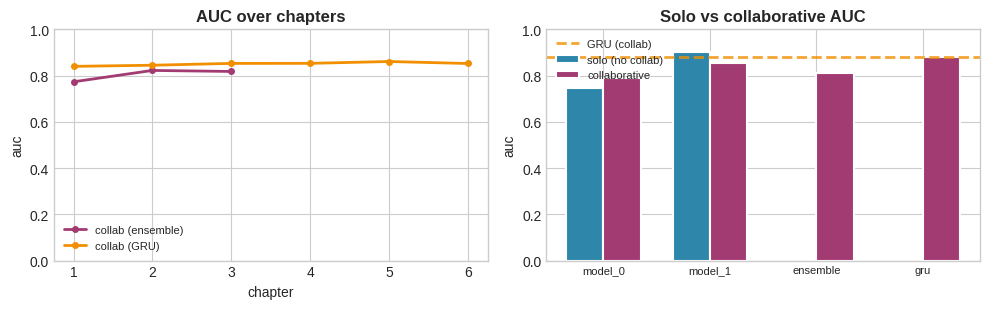

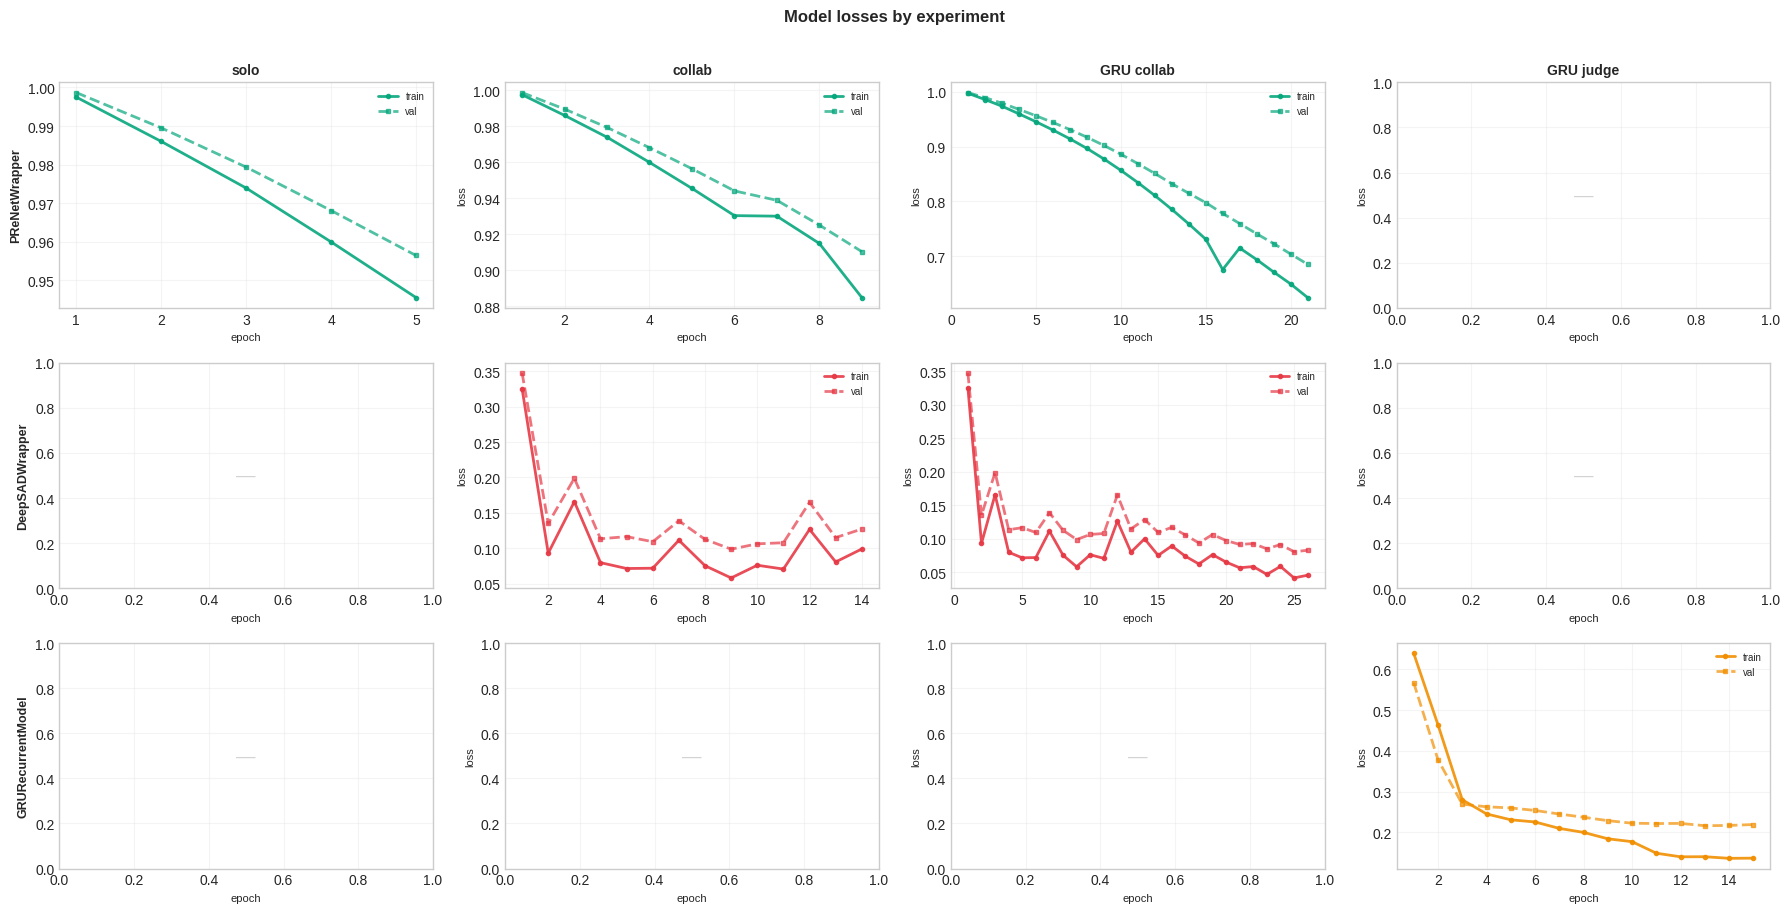

In [13]:
import matplotlib.pyplot as plt
from collections import defaultdict, OrderedDict
%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "solo": "#2E86AB",
    "collab": "#A23B72",
    "gru": "#F18F01",
    "prenet": "#06A77D",
    "deepsad": "#E63946",
    "ensemble": "#8338EC",
}

def _plot_auc(histories, labels, ax, title):
    colors_map = ["#A23B72", "#F18F01"]
    for i, (hist, label) in enumerate(zip(histories, labels)):
        if not hist or "chapters" not in hist or not hist["chapters"]:
            continue
        chapters = hist["chapters"]
        x = np.arange(1, len(chapters) + 1)
        y = [c.get("ensemble", np.nan) for c in chapters]
        ax.plot(x, y, marker="o", linewidth=2, markersize=4, label=label, color=colors_map[i])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("chapter"); ax.set_ylabel("auc"); ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8)

def _plot_solo_vs_collab(solo, collab, gru_val, ax, title):
    if not solo or not collab:
        return
    keys = [k for k in collab.keys() if k in solo]
    if "ensemble" in collab:
        keys.append("ensemble")
    labels = keys + (["gru"] if gru_val is not None else [])
    solo_vals = [solo.get(k, np.nan) for k in keys] + ([np.nan] if gru_val is not None else [])
    collab_vals = [collab.get(k, np.nan) for k in keys] + ([gru_val] if gru_val is not None else [])
    x = np.arange(len(labels)); w = 0.35
    ax.bar(x - w/2, solo_vals, width=w, label="solo (no collab)", color=COLORS["solo"], edgecolor="white", linewidth=1.5)
    ax.bar(x + w/2, collab_vals, width=w, label="collaborative", color=COLORS["collab"], edgecolor="white", linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("auc"); ax.set_ylim(0.0, 1.0)
    if gru_val is not None and not np.isnan(gru_val):
        ax.axhline(y=gru_val, color=COLORS["gru"], linestyle="--", linewidth=2, label="GRU (collab)", alpha=0.8)
    ax.legend(fontsize=8, loc="best")

# ── AUC overview ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
_plot_auc([history, history_gru], ["collab (ensemble)", "collab (GRU)"], axes[0], "AUC over chapters")
_plot_solo_vs_collab(solo_results, collab_metrics, gru_auc if 'gru_auc' in globals() else None, axes[1], "Solo vs collaborative AUC")
fig.tight_layout(); plt.show()

# ── Loss mosaic: rows = model type, cols = experiment ──
color_map = {
    "PReNetWrapper": COLORS["prenet"],
    "DeepSADWrapper": COLORS["deepsad"],
    "GRURecurrentModel": COLORS["gru"],
}
experiments = OrderedDict([
    ("solo", [prenet]),
    ("collab", models if 'models' in globals() else []),
    ("GRU collab", models_gru if 'models_gru' in globals() else []),
])
# Build grid[model_type][experiment] = model
grid = OrderedDict()
for exp, ms in experiments.items():
    ms = ms if isinstance(ms, list) else [ms]
    for m in ms:
        name = m.__class__.__name__
        grid.setdefault(name, OrderedDict())[exp] = m
# Append GRU judge as its own row
grid["GRURecurrentModel"] = {"GRU judge": gru_model}

row_names = list(grid.keys())
col_set = []
for row_data in grid.values():
    for c in row_data:
        if c not in col_set:
            col_set.append(c)

nrows = len(row_names)
ncols = len(col_set)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows), squeeze=False)

for r, model_type in enumerate(row_names):
    row_data = grid[model_type]
    color = color_map.get(model_type, "#555555")
    for c, exp in enumerate(col_set):
        ax = axes[r][c]
        m = row_data.get(exp)
        has = False
        if m is not None:
            train = getattr(m, "_train_loss_history", None)
            val = getattr(m, "_val_loss_history", None)
            if train:
                ax.plot(np.arange(1, len(train)+1), train, marker="o", linewidth=2,
                        markersize=3, color=color, label="train", alpha=0.9)
                has = True
            if val:
                ax.plot(np.arange(1, len(val)+1), val, marker="s", linewidth=2,
                        markersize=3, color=color, linestyle="--", label="val", alpha=0.7)
                has = True
            if not has:
                last = getattr(m, "_last_loss", None)
                if last is not None:
                    ax.plot([1], [last], marker="o", markersize=6, color=color, label="last loss")
                    has = True
        if has:
            ax.legend(fontsize=7, loc="best")
        else:
            ax.text(0.5, 0.5, "—", ha="center", va="center", transform=ax.transAxes, fontsize=14, color="lightgray")
        ax.set_xlabel("epoch", fontsize=8); ax.set_ylabel("loss", fontsize=8)
        ax.grid(True, alpha=0.2)
        # Row / col headers
        if c == 0:
            ax.set_ylabel(model_type, fontsize=9, fontweight="bold")
        if r == 0:
            ax.set_title(exp, fontweight="bold", fontsize=10)

fig.suptitle("Model losses by experiment", fontweight="bold", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()